# Round 009 — T2 factor momentum

ตัวเลขทั้งหมดอ่านจาก `results.csv` ที่ `run.py` ของ round นี้เขียนไว้ · ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023 · ⚠️ survivorship: ราคาของหุ้นที่ออกจากตลาดไปแล้วหายบางส่วน → ผลอาจดูดีเกินจริง · held-out (ตั้งแต่ ก.ค. 2023) ไม่ถูกใช้

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_009/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r009_FMOM_SIGNALS,0.597,0.64,0.681,0.118,0.125,-0.351,-0.376,False,False,0.514,0.003,79.083,50,0.962,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


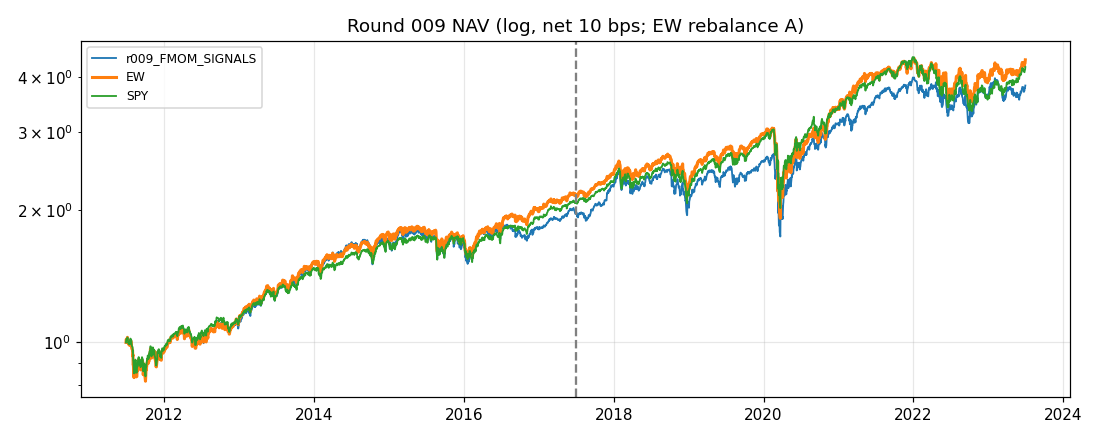

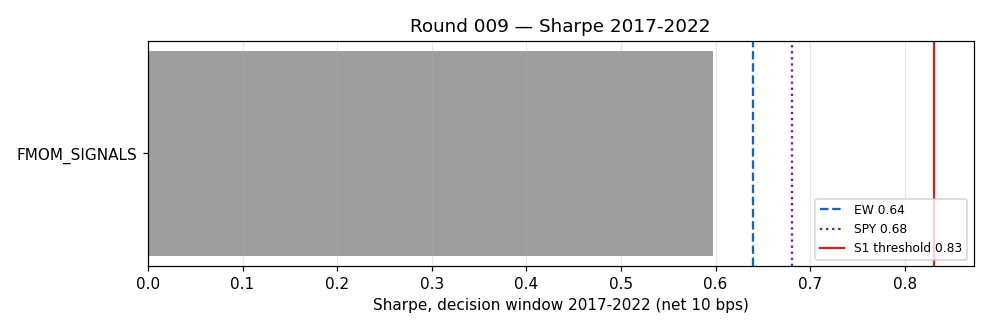

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_009_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_009/RESULTS.md").read_text()))

# Round 009 — EXPLORE2 T2: factor momentum — **ไม่มีผู้เข้ารอบ**

## ขั้น 1 — Ken French 6 ภูมิภาค (ไม่นับ trial)
| region | series | start | months | mean_ann_% | Sharpe | t |
|---|---|---|---|---|---|---|
| US | FMOM | 1964-07-31 | 708 | 5.633 | 0.730 | 5.609 |
| US | EQUAL | 1964-07-31 | 708 | 3.967 | 0.861 | 6.614 |
| US | FMOM-EQUAL | 1964-07-31 | 708 | 1.666 | 0.291 | 2.238 |
| Developed_ex_US | FMOM | 1991-07-31 | 384 | 5.240 | 0.910 | 5.148 |
| Developed_ex_US | EQUAL | 1991-07-31 | 384 | 3.739 | 1.032 | 5.839 |
| Developed_ex_US | FMOM-EQUAL | 1991-07-31 | 384 | 1.501 | 0.393 | 2.224 |
| Europe | FMOM | 1991-07-31 | 384 | 6.781 | 1.044 | 5.905 |
| Europe | EQUAL | 1991-07-31 | 384 | 4.058 | 1.052 | 5.952 |
| Europe | FMOM-EQUAL | 1991-07-31 | 384 | 2.723 | 0.617 | 3.492 |
| Japan | FMOM | 1991-07-31 | 384 | 3.400 | 0.419 | 2.372 |
| Japan | EQUAL | 1991-07-31 | 384 | 1.455 | 0.352 | 1.992 |
| Japan | FMOM-EQUAL | 1991-07-31 | 384 | 1.946 | 0.289 | 1.637 |
| Asia_Pacific_ex_Japan | FMOM | 1991-07-31 | 384 | 5.881 | 0.770 | 4.356 |
| Asia_Pacific_ex_Japan | EQUAL | 1991-07-31 | 384 | 4.370 | 0.981 | 5.551 |
| Asia_Pacific_ex_Japan | FMOM-EQUAL | 1991-07-31 | 384 | 1.511 | 0.306 | 1.730 |
| Emerging | FMOM | 1990-07-31 | 396 | 6.311 | 1.193 | 6.853 |
| Emerging | EQUAL | 1990-07-31 | 396 | 4.972 | 1.275 | 7.323 |
| Emerging | FMOM-EQUAL | 1990-07-31 | 396 | 1.340 | 0.355 | 2.038 |

- FMOM (ถือเฉพาะ factor ที่ 12 เดือนย้อนหลังเป็นบวก) ได้ผลตอบแทนเฉลี่ยสูงกว่าถือเท่ากัน **ทั้ง 6 ภูมิภาค** (ส่วนต่าง +1.3 ถึง +2.7%/ปี, t 1.6–3.5)
  สอดคล้องกับงานต้นฉบับ — **แต่ Sharpe ของ FMOM ต่ำกว่าถือเท่ากันใน 5/6 ภูมิภาค** (ผันผวนมากขึ้นเพราะกระจุก factor น้อยตัว)

## ขั้น 2 — สัญญาณของเรา (1 trial → สะสม 119)
| trial | Sharpe | EW | SPY | CAGR (EW) | MaxDD (EW) | S1 | S2 | DSR | ช่วง 2011–16 (EW) |
|---|---|---|---|---|---|---|---|---|---|
| `r009_FMOM_SIGNALS` | 0.597 | 0.640 | 0.681 | 11.8% (12.5%) | -35.1% (-37.6%) | False | 51% | 0.003 | 0.962 (1.137) |

spread ปีก่อน (Q5 − Q1) ที่ใช้ตัดสินเลือกสัญญาณ:
| R | A_SHY | C_MOM | Q_GPA | Q_LOWACC | V_EP |
|---|---|---|---|---|---|
| 2012-06-29 | 0.133 | -0.057 | 0.143 | 0.029 | 0.025 |
| 2013-06-28 | -0.013 | -0.161 | -0.090 | -0.061 | 0.041 |
| 2014-06-30 | -0.056 | 0.142 | -0.195 | 0.061 | -0.008 |
| 2015-06-30 | 0.057 | -0.041 | 0.184 | -0.035 | -0.060 |
| 2016-06-30 | -0.027 | 0.135 | 0.043 | -0.044 | -0.023 |
| 2017-06-30 | 0.128 | -0.029 | -0.156 | -0.063 | 0.148 |
| 2018-06-29 | 0.037 | 0.077 | 0.165 | 0.150 | -0.104 |
| 2019-06-28 | -0.026 | -0.061 | 0.054 | -0.063 | -0.079 |
| 2020-06-30 | -0.070 | 0.241 | 0.182 | 0.021 | -0.246 |
| 2021-06-30 | 0.279 | -0.478 | 0.010 | 0.199 | 0.031 |
| 2022-06-30 | 0.208 | -0.169 | -0.050 | 0.086 | 0.089 |

## การตีความ
ในหุ้นใหญ่ S&P 500 ผลของสัญญาณ "ปีก่อน" สลับเครื่องหมายบ่อย (เช่น momentum +0.241 ปี 2020 → −0.478 ปี 2021) จึงไม่ช่วยเลือกสัญญาณปีถัดไป;
factor momentum ระดับ factor ทั่วโลกให้ผลตอบแทนเพิ่มจริงแต่ไม่ได้ปรับ Sharpe ให้ดีขึ้น
